In [1]:
%load_ext autoreload
%autoreload 2  

import sys, os, re

dir_home = re.sub( 'QBioCode.*', 'QBioCode', os.getcwd() )
sys.path.append( dir_home )
import qbiocode as qbc

dir_home = '../../apps/'
sys.path.append( dir_home )


# Example of how to run QProfiler to perform Quantum Projection Learning

Quantum projection learning (QPL) is a variant of Projected Quantum Kernels, where rather than analyzing the quantum projected data with only a classical kernel method, QPL uses additional classical learners.  In total the quantum projected data is analyzed with support vector classifier (SVC), random forest classifier (RF), extreme gradient boosting classifier (xgb), multilayer perceptron classifier (MLP), and logistic regression classifer (LR). 


## Generate data some test data

In [2]:

type_of_data = 'classes'

N_SAMPLES = [20]
N_FEATURES = [10]
N_INFORMATIVE = [2]
N_REDUNDANT = [2]
N_CLASSES = [2]
N_CLUSTERS_PER_CLASS = [2]
WEIGHTS = [[0.3, 0.7], [0.4, 0.6], [0.5, 0.5]]

qbc.generate_data(
    type_of_data=type_of_data,
    save_path= os.path.join( 'data', 'ld_data' ),
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    n_informative=N_INFORMATIVE,
    n_redundant=N_REDUNDANT,
    n_classes=N_CLASSES,
    n_clusters_per_class=N_CLUSTERS_PER_CLASS,
    weights=WEIGHTS,
)

Generating classes dataset...
Dataset generation complete.


## Running QProfiler

To run QProfiler, configure a YAML that will capture the experimental parameters you are interested in testing.  

For our purposes, we need only specify the model as 'pqk', and if desired the 'pqk' model parameters may be adjusted, is our experiment's yaml file in ```config/pqk.yaml```

QProfiler can be called from the commandline as below
```
python qprofiler.py --config-path=[path to QBioCode]/tutorial/Qauntum_Projection_Learning/configs --config-name=pqk.yaml
```

Or as follows

In [ ]:
import qprofiler.qprofiler as profiler
import yaml

config = yaml.safe_load(open('configs/qpl.yaml', 'r'))

profiler.main(config)

Let us also analyze the data with XGB as a classical baseline using ```configs/xgb.yaml```

In [ ]:
config = yaml.safe_load(open('configs/xgb.yaml', 'r'))

profiler.main(config)

## Visualize results

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import math

data_evals = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.getcwd()) for f in filenames if f == 'RawDataEvaluation.csv']
data_result = [os.path.join(dp, f) for dp, dn, filenames in os.walk(os.getcwd()) for f in filenames if f == 'ModelResults.csv']

rawevals_df=[]
for fl in data_evals:
    rawevals_df.append(pd.read_csv(fl))
rawevals_df = pd.concat(rawevals_df)
# this will create a dataframe with all the data complexity evaluations, and save it to a csv file
rawevals_df.to_csv( 'compiled_raw_data_evaluations.csv', index=False )
results_df = []
for fl in data_result:
    results_df.append( pd.read_csv(fl) )
results_df = pd.concat( results_df )
# these two lines below add a couple columns to the dataframe, consolidating certain information that will be useful for plotting later
results_df['datatype'] = [ re.sub( '-.*', '', x ) for x in results_df['Dataset'] ]
results_df[ 'model_embed_datatype'] = [ row.model + '_' + row.embeddings + '_' + row.datatype for idx, row in results_df.iterrows() ]
# this will create a dataframe with all the data model results, and save it to a csv file
results_df.to_csv( 'compiled_results.csv', index=False )

# use this tag to give a quick name for all outputs, reflecting what your input data sets were
tag = 'tutorial_data'

## establish output directory 
output_dir =  'performance_summary_and_spearman_correlation_plots'
if not os.path.exists( output_dir ):
    os.makedirs( output_dir )

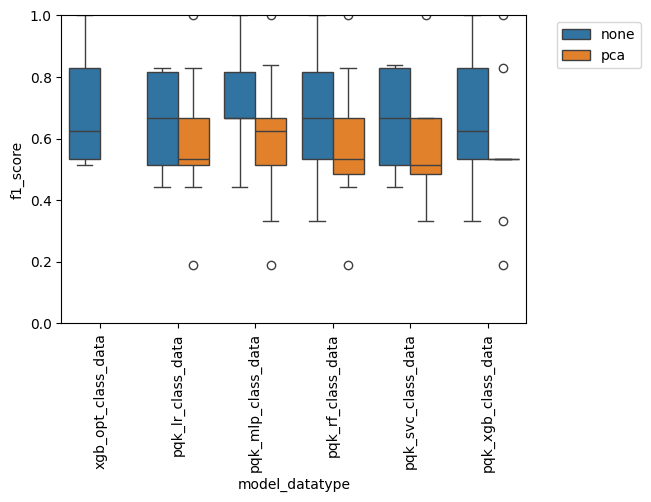

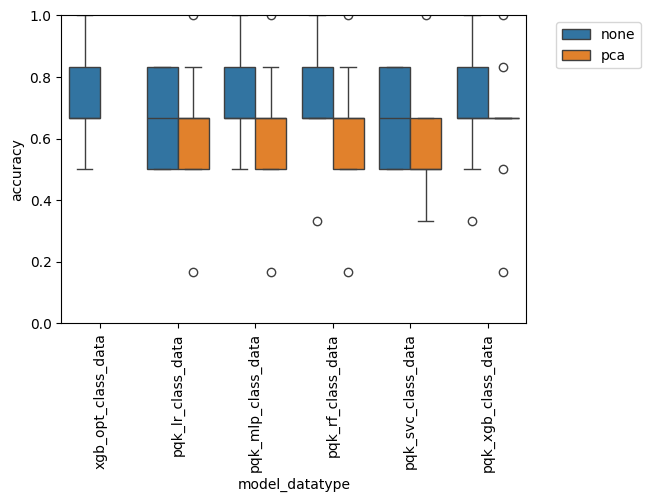

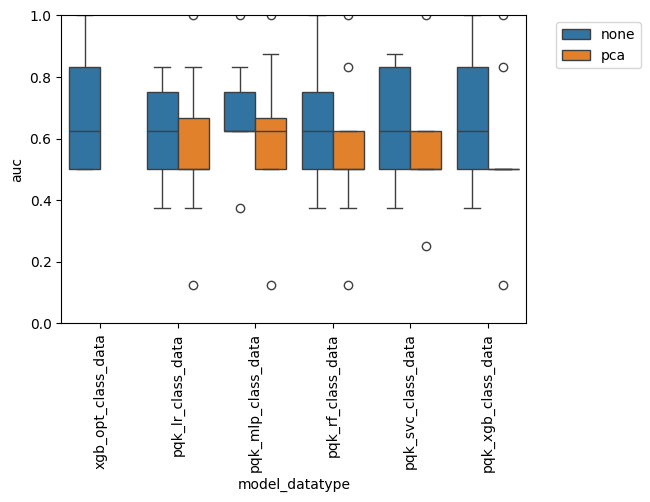

In [46]:
results_df['model_datatype'] = ['_'.join( [row.model, row.datatype] )  for idx, row in results_df.iterrows()]
for m in ['f1_score','accuracy', 'auc']:
    plt.figure( figsize=(6,4) )
    sns.boxplot( data = results_df, x = 'model_datatype', y = m, hue = 'embeddings' )
    plt.ylim( 0, 1)
    plt.xticks(rotation = 90 )
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig( os.path.join( output_dir, tag + f'_{m}_boxplot.png'), bbox_inches='tight' )
    plt.show()
    plt.close()

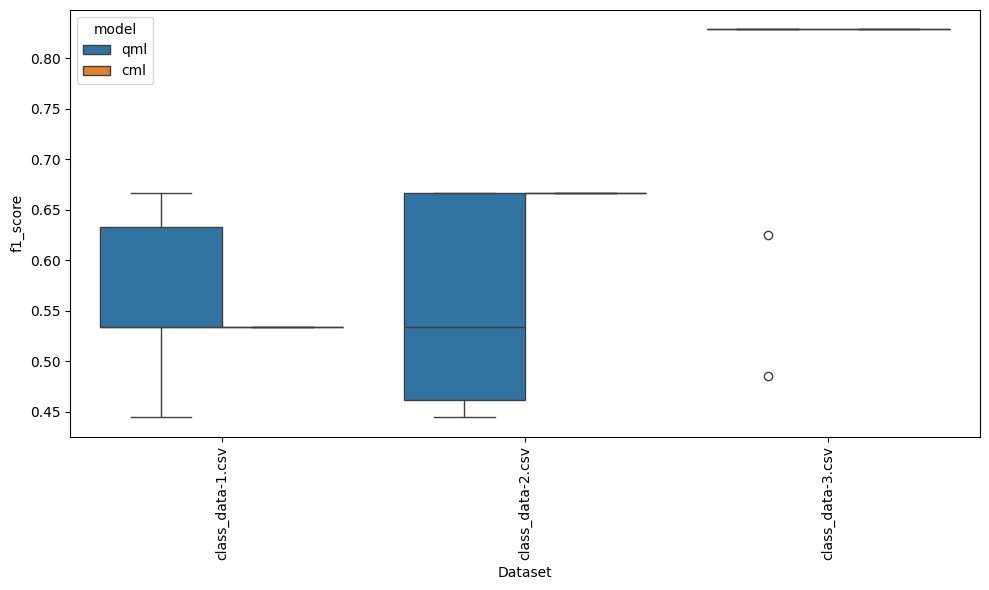

In [47]:
# Get the datasets for which the qml did better
# If there were no datasets in which QML outperformed CML, this cell returns a blank plot.
models_qml = ['pqk_lr', 'pqk_svc', 'pqk_rf', 'pqk_mlp', 'pqk_xgb' ]
df = results_df.copy()
df_across_split= df.groupby(['Dataset', 'embeddings', 'model'])['f1_score'].median().reset_index()
best_per_dataset = df_across_split.loc[df_across_split.groupby('Dataset')['f1_score'].idxmax()]
qml_winner = df_across_split[df_across_split['Dataset'].isin(best_per_dataset[best_per_dataset['model'].isin(models_qml)]['Dataset'])]
qml_winner['model'] = [ 'qml' if x in models_qml else 'cml' for x in qml_winner['model'] ]
plt.figure( figsize=(10,6))
ax = sns.boxplot( data = qml_winner, x = 'Dataset', y = 'f1_score', hue = 'model' )
# sns.swarmplot( data = qml_winner, x = 'Dataset', y = 'f1_score', hue = 'model', ax = ax )
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()
plt.close()